# 03 - What is this pipeline good for?

Notebooks 01 and 02 measured the data. This one turns those measurements into a statement
about use case: which failures the technique can reach, how much compute that is worth, and
where it should not be applied. Nothing here trains a model.

**Every number below is what one hypothetical detector would achieve.** Call it the oracle:

* it is **never wrong** - no false alarms, no misses, no threshold to tune;
* it sees only what the pipeline would show it - a window of 40 gap-free snapshots from one
  job on one node - so a job that never produces a complete window is invisible to it;
* it may only alert on a window the labelling scheme calls **positive**, which means inside
  the 2-hour horizon, however long the job ran;
* an alert stops the job at once, and whatever compute was already spent is gone.

A real model is strictly worse on every line, so a ceiling that is already low is a reason to
change the problem rather than the algorithm.

**Two units, two different answers.** Coverage is counted in **jobs** - how many failures
could be warned about. Value is counted in **node-hours** - how much compute that saves. The
two disagree sharply, and section 2 is where the disagreement is resolved.

1. Which failures can be seen at all, and how early? *(jobs)*
2. What could the oracle actually save? *(node-hours)*
3. The floor: what you get without any telemetry.
4. The per-state verdict.
5. What the pipeline is good for.
6. What would move the ceiling.
7. Threats to validity.

In [1]:
# --- Setup: paths, constants, plotting -------------------------------------
# This block is repeated verbatim at the top of all three notebooks so that each
# one can be read and run on its own. The notebooks share *data* (the parquet
# files written into data/), never code.
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW    = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
HWINFO = ROOT / "dataset" / "node_hardware_info.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# --- Pipeline constants ----------------------------------------------------
WINDOW     = 40     # snapshots per window -> 20 minutes at a 30 s cadence
HORIZON_H  = 2.0    # a snapshot is positive within 2 h of a failing job's end
GAP_TOL_S  = 60.0   # reject any window that contains a larger gap than this
STRIDE     = 10     # keep every 10th window start inside a series
TRAIN_FRAC = 0.8    # temporal split: the first 80 % of jobs by end_date
SNAP_S     = 30.0   # telemetry cadence, verified in notebook 01

# "OOM" always denotes the OUT_OF_MEMORY *job state*, never a machine that ran
# out of RAM.
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})

def save(fig, name):
    """Write a figure into figures/ and return it so the cell still displays it."""
    fig.savefig(FIGS / name, bbox_inches="tight")
    return fig

print("dataset:", RAW, "|", "found" if RAW.exists() else "MISSING")

dataset: D:\_fcall\UNIFEI\tcc\hpc_workload\dataset\prom_slurm_joined\prom_slurm_joined.parquet | found


In [2]:
jobs = pd.read_parquet(DATA / "jobs.parquet")
W = pd.read_parquet(DATA / "windows.parquet",
                    columns=["slurm_id", "node", "state", "nodetypes", "numnodes",
                             "t_end", "ttf_end", "y", "split"])
print(f"{len(jobs):,} jobs | {len(W):,} windows")

# The earliest window a job produces: the largest time-to-end among its windows.
# The first window of a series always survives the stride, so this really is the
# earliest opportunity to warn, not an artefact of subsampling.
lead = W.groupby("slurm_id").ttf_end.max().rename("best_lead_s")
jobs = jobs.merge(lead, left_on="slurm_id", right_index=True, how="left")
jobs["best_lead_h"] = jobs.best_lead_s / 3600
jobs["observable"] = jobs.best_lead_s.notna()
fail = jobs[jobs.is_failure]
print(f"failing jobs: {len(fail):,}, of which {int(fail.observable.sum()):,} "
      f"produce at least one window ({fail.observable.mean():.1%})")

23,618 jobs | 1,057,817 windows
failing jobs: 6,312, of which 2,097 produce at least one window (33.2%)


## 1. Which failures can be seen at all, and how early?

A warning is only useful if it arrives with time to act. So for each failing job: does it
produce a window at all, and does that window end at least `L` minutes before the job dies?
`L = 0` is the weakest possible requirement - merely being visible - and larger `L` is what an
operator would actually need.

In [3]:
LEADS = [0, 10, 20, 30, 60, 120]
rows = []
for s in FAILURE_STATES:
    d = jobs[jobs.state == s]
    r = {"state": s, "failing jobs": len(d)}
    for L in LEADS:
        r[f">={L}m"] = float((d.best_lead_h.fillna(-1) >= L / 60).mean())
    rows.append(r)
d = fail
r = {"state": "ALL FAILURES", "failing jobs": len(d)}
for L in LEADS:
    r[f">={L}m"] = float((d.best_lead_h.fillna(-1) >= L / 60).mean())
rows.append(r)
obs = pd.DataFrame(rows).set_index("state")
print(obs.to_string(formatters={f">={L}m": "{:.1%}".format for L in LEADS}))

               failing jobs  >=0m >=10m >=20m >=30m >=60m >=120m
state                                                           
FAILED                 4664 15.3% 13.2% 11.8% 10.4%  8.4%   6.6%
TIMEOUT                1411 91.5% 90.0% 89.0% 88.7% 74.5%  62.6%
OUT_OF_MEMORY           130 43.8% 39.2% 33.1% 32.3% 30.0%  17.7%
NODE_FAIL               107 33.6% 26.2% 24.3% 23.4% 15.0%   9.3%
ALL FAILURES           6312 33.2% 31.1% 29.7% 28.6% 23.7%  19.4%


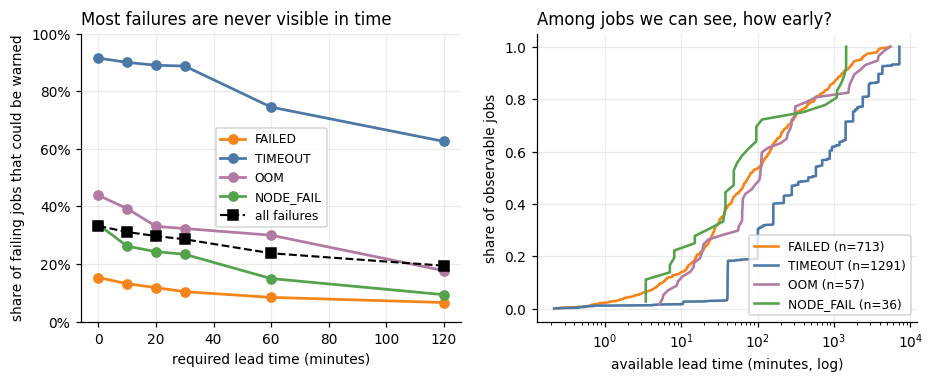

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.4))
ax = axes[0]
for s in FAILURE_STATES:
    ax.plot(LEADS, [obs.loc[s, f">={L}m"] for L in LEADS], marker="o", color=COLOR[s],
            lw=1.8, label=s.replace("OUT_OF_MEMORY", "OOM"))
ax.plot(LEADS, [obs.loc["ALL FAILURES", f">={L}m"] for L in LEADS], marker="s", color="k",
        ls="--", lw=1.4, label="all failures")
ax.set_xlabel("required lead time (minutes)")
ax.set_ylabel("share of failing jobs that could be warned")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.set_title("Most failures are never visible in time", loc="left")

ax = axes[1]
for s in FAILURE_STATES:
    v = np.sort(jobs.loc[(jobs.state == s) & jobs.observable, "best_lead_h"].to_numpy() * 60)
    if len(v) > 5:
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=COLOR[s], lw=1.7,
                label=f"{s.replace('OUT_OF_MEMORY','OOM')} (n={len(v)})")
ax.set_xscale("log"); ax.set_xlabel("available lead time (minutes, log)")
ax.set_ylabel("share of observable jobs")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Among jobs we can see, how early?", loc="left")
save(fig, "16_lead_time.png"); plt.show()

This is the coverage constraint in one table, and it is severe. Taking 20 minutes as the
minimum useful lead, under a third of failures are reachable at all - and that is before any
model makes a single mistake.

The states behave completely differently, which is the main argument against pooling them.
`TIMEOUT` jobs run for hours, so nearly all of them are visible with hours to spare. `FAILED`
jobs mostly die within a minute or two, and no amount of modelling reaches them. `OOM` and
`NODE_FAIL` sit in between, on very small samples.

## 2. What could the oracle actually save?

Section 1 counted jobs. Value has to be counted in the unit a cluster operator budgets:
**node-hours**, `numnodes x runtime`. The prize is the node-hours burned by jobs that ended in
a failure state, and the cascade below strips that prize down one loss at a time.

| line | what it is | what the step removes |
|---|---|---|
| burned | every node-hour spent on a job that ended in a failure state | - |
| observable 20 min ahead | of that, the jobs the oracle can see in time | jobs too short to produce a window |
| alert at the first window | a **counterfactual**: the oracle allowed to fire the moment a job has 20 minutes of history | the warm-up before the first window closes |
| recoverable | the real bound: an alert may only fire on a *positive* window, i.e. inside the last 2 h | everything the job burned before the horizon opened |

The third line is not achievable under the current labelling - it is there so that the fourth
line can be read as a price. The gap between them is what the horizon costs, and it is the
number this section exists to expose.

In [5]:
MIN_LEAD_H = 20 / 60
total_nh = float(jobs.node_hours.sum())
jobs["reachable"] = jobs.is_failure & (jobs.best_lead_h.fillna(-1) >= MIN_LEAD_H)

# The oracle may only alert on a window the labelling scheme calls positive, and a window is
# positive only inside the horizon. So the lead time available to it is the largest
# time-to-end among that job's POSITIVE windows, which HORIZON_H caps at 2 h however long the
# job ran.
pos_lead_h = W.loc[W.y == 1].groupby("slurm_id").ttf_end.max() / 3600
jobs["alert_lead_h"] = jobs.slurm_id.map(pos_lead_h)
jobs["recoverable_nh"] = (jobs.numnodes * jobs.alert_lead_h.fillna(0)).where(
    jobs.is_failure, 0.0)
# Counterfactual: the same oracle, allowed to alert at the job's FIRST window.
jobs["nolimit_nh"] = np.where(jobs.reachable, jobs.numnodes * jobs.best_lead_h.fillna(0), 0.0)

prize    = float(jobs.loc[jobs.is_failure, "node_hours"].sum())
reach_nh = float(jobs.loc[jobs.reachable, "node_hours"].sum())
rec_max  = float(jobs.nolimit_nh.sum())
rec      = float(jobs.recoverable_nh.sum())

print(f"cluster total      {total_nh:>10,.0f} node-hours over {len(jobs):,} jobs")
print(f"burned by failures {prize:>10,.0f} node-hours ({prize/total_nh:.1%} of the cluster)")
print()

# The last line counts every failing job with a positive window. 222 of them sit below the
# 20-minute bar and contribute 30 nh, so it stands 0.08 % above a strictly nested cascade.
cascade = [
    ("burned by failing jobs",                        prize,    ""),
    ("observable 20 min ahead",                       reach_nh, "jobs too short to be seen in time"),
    ("[counterfactual] alert at the first window",    rec_max,  "the warm-up before the first window"),
    (f"recoverable: alert inside the {HORIZON_H:.0f} h horizon", rec, "burned before the horizon opened"),
]
prev = None
for name, v, lost in cascade:
    drop = "" if prev is None else f"{'-' + format(prev - v, ',.0f'):>11}   {lost}"
    print(f"  {name:<44}{v:>9,.0f} nh{v/prize:>8.1%}{drop}")
    prev = v

by = jobs.groupby("state", observed=True)
econ = pd.DataFrame({
    "jobs": by.size(),
    "burned_nh": by.node_hours.sum(),
    "reachable_jobs": by.reachable.sum(),
    "reachable_nh": jobs[jobs.reachable].groupby("state", observed=True).node_hours.sum(),
    "recoverable_nh": by.recoverable_nh.sum(),
}).reindex(STATES).fillna(0)
econ["share_of_prize"] = econ.burned_nh / prize
econ.loc["COMPLETED", "share_of_prize"] = np.nan

print()
print("the same cascade, per state:")
print(econ.to_string(formatters={
    "burned_nh": "{:,.0f}".format, "reachable_nh": "{:,.0f}".format,
    "recoverable_nh": "{:,.0f}".format, "share_of_prize": "{:.1%}".format,
    "reachable_jobs": "{:,.0f}".format}))

cluster total          95,261 node-hours over 23,618 jobs
burned by failures     37,249 node-hours (39.1% of the cluster)

  burned by failing jobs                         37,249 nh  100.0%
  observable 20 min ahead                        36,967 nh   99.2%       -282   jobs too short to be seen in time
  [counterfactual] alert at the first window     36,170 nh   97.1%       -797   the warm-up before the first window
  recoverable: alert inside the 2 h horizon       2,887 nh    7.8%    -33,284   burned before the horizon opened

the same cascade, per state:
                jobs burned_nh reachable_jobs reachable_nh recoverable_nh share_of_prize
state                                                                                   
COMPLETED      17306    58,012              0            0              0            NaN
FAILED          4664     5,343            550        5,127            778          14.3%
TIMEOUT         1411    31,044          1,256       31,009          2,004        

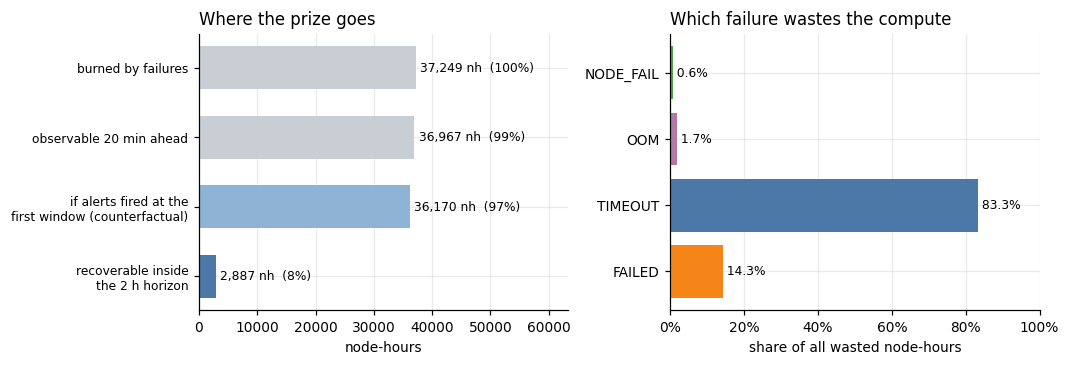

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.4))
ax = axes[0]
vals = [v for _, v, _ in cascade]
ypos = np.arange(len(vals))[::-1]
ax.barh(ypos, vals, height=0.62, color=["#c9ced4", "#c9ced4", "#8fb3d4", "#4c78a8"])
ax.set_yticks(ypos, ["burned by failures", "observable 20 min ahead",
                     "if alerts fired at the\nfirst window (counterfactual)",
                     f"recoverable inside\nthe {HORIZON_H:.0f} h horizon"], fontsize=8)
for y, v in zip(ypos, vals):
    ax.text(v + prize * 0.02, y, f"{v:,.0f} nh  ({v/prize:.0%})", va="center", fontsize=8)
ax.set_xlim(0, prize * 1.70); ax.set_xlabel("node-hours")
ax.set_title("Where the prize goes", loc="left")

ax = axes[1]
f_states = list(FAILURE_STATES)
sh = econ.loc[f_states, "burned_nh"] / prize
ax.barh(range(len(f_states)), sh.values, color=[COLOR[s] for s in f_states])
ax.set_yticks(range(len(f_states)), [s.replace("OUT_OF_MEMORY", "OOM") for s in f_states])
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("share of all wasted node-hours")
for i, v in enumerate(sh.values):
    ax.text(v, i, f" {v:.1%}", va="center", fontsize=8)
ax.set_xlim(0, max(sh.values) * 1.2)
ax.set_title("Which failure wastes the compute", loc="left")
fig.tight_layout()
save(fig, "17_node_hours.png"); plt.show()

Two facts dominate everything that follows.

**TIMEOUT owns the prize.** It is a small minority of failing jobs but 83 % of the wasted
node-hours, because those jobs run for hours by definition. Notebook 01 showed TIMEOUT is a
walltime under-estimate rather than a sick node, so most of the value on the table is not
node health at all.

**The horizon, not the coverage, is what caps the value.** This is where the two units
disagree, and the cascade settles it. By job count only 30 % of failures are observable,
which sounds fatal - but those few are the long ones, and they hold 99 % of the wasted
node-hours: coverage costs 282 node-hours, under 1 % of the prize. The loss is almost
entirely in the last step. A window counts as positive only inside the final two hours, so a
job that wastes a hundred node-hours can only ever be caught in its last two, and 89 % of the
prize disappears there.

Both readings are defensible and they point in opposite directions. Framed as *warning a
user*, the horizon is right: a warning two hours out is actionable, one twenty hours out is
noise. Framed as *reclaiming compute*, the horizon should be far wider and the label
redefined to match. What is not defensible is quoting a score obtained under the first
framing as though it measured the second.

## 3. The floor: what you get without any telemetry

Everything above is an upper bound. This is the lower one. Each job is submitted to a queue,
and notebook 01 showed the queues have wildly different failure rates - from 16 % to 86 %. So:
score each *test* job by the failure rate of its queue, measured on *train* jobs only. No
telemetry, no window, no model - one `groupby` on information known before the job starts.

This does not solve the same problem. It predicts *whether* a job will fail, not *when*, so it
cannot trigger a timed warning. It is here to calibrate expectations: if submission metadata
alone were already strong, telemetry would have little left to add.

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score

tr, te = jobs[jobs.split == "train"], jobs[jobs.split == "test"]
rate = tr.groupby("nodetypes", observed=True).is_failure.mean()
# plain dict: mapping a categorical Series returns a categorical, which cannot then be
# filled with a float
rate_by_queue = {str(k): float(v) for k, v in rate.items()}
score = (te.nodetypes.astype(str).map(rate_by_queue)
           .astype(float).fillna(tr.is_failure.mean()).to_numpy())
truth = te.is_failure.to_numpy()

print(f"test jobs: {len(te):,}, failure rate {truth.mean():.1%}")
print(f"queue-only baseline   ROC-AUC {roc_auc_score(truth, score):.3f} | "
      f"PR-AUC {average_precision_score(truth, score):.3f} "
      f"(lift {average_precision_score(truth, score)/truth.mean():.2f}x)")
for extra, name in ((te.numcores.to_numpy(), "numcores"), (te.numnodes.to_numpy(), "numnodes")):
    print(f"  {name} alone         ROC-AUC {roc_auc_score(truth, extra):.3f}")

test jobs: 4,724, failure rate 24.5%
queue-only baseline   ROC-AUC 0.544 | PR-AUC 0.301 (lift 1.23x)
  numcores alone         ROC-AUC 0.415
  numnodes alone         ROC-AUC 0.501


Queue identity is only weakly informative at job level: the queues with the extreme failure
rates are also the smallest, so they barely move the ranking. `numcores` scores below 0.5,
meaning smaller jobs fail more often - inverted it would reach 0.585.

So the floor is low, which is the useful part. A telemetry model answers a different question
(*when*, per window) and cannot be compared to these numbers directly, but any claim that
job-level failure is predictable from submission metadata has to clear 0.54 first.

## 4. The per-state verdict

Everything the three notebooks measured, one row per failure state.

In [8]:
f01 = json.load(open(DATA / "facts_01.json"))
f02 = json.load(open(DATA / "facts_02.json"))

wstate = W.groupby("state", observed=True).agg(windows=("y", "size"), positives=("y", "sum"))
idx = list(STATES)                      # every column is reindexed onto this order
by = jobs.groupby("state", observed=True)
verdict = pd.DataFrame(index=idx)
verdict["jobs"] = by.size().reindex(idx)
verdict["share of failures"] = by.size().reindex(idx) / len(fail)
verdict["median runtime"] = by.slurm_h.median().reindex(idx) * 60
verdict["observable >=20 min"] = pd.Series(
    {s: float((jobs.loc[jobs.state == s, "best_lead_h"].fillna(-1) >= MIN_LEAD_H).mean())
     for s in idx})
verdict["positive windows"] = wstate.positives.reindex(idx)
verdict["node-hours burned"] = econ.burned_nh.reindex(idx)
verdict["share of prize"] = econ.share_of_prize.reindex(idx)
verdict = verdict.loc[list(FAILURE_STATES)]
print(verdict.to_string(formatters={
    "share of failures": "{:.1%}".format, "median runtime": "{:.1f} min".format,
    "observable >=20 min": "{:.1%}".format, "positive windows": "{:,.0f}".format,
    "node-hours burned": "{:,.0f}".format, "share of prize": "{:.1%}".format}))
verdict.to_csv(DATA / "verdict.csv")

               jobs share of failures median runtime observable >=20 min positive windows node-hours burned share of prize
FAILED         4664             73.9%        1.0 min               11.8%            9,491             5,343          14.3%
TIMEOUT        1411             22.4%      300.2 min               89.0%           24,926            31,044          83.3%
OUT_OF_MEMORY   130              2.1%       11.5 min               33.1%              830               625           1.7%
NODE_FAIL       107              1.7%       10.1 min               24.3%              418               237           0.6%


* **TIMEOUT** - 83 % of the wasted node-hours, almost always observable, thousands of positive
  windows. It is also the only state whose "failure" is a walltime policy rather than a fault:
  worth the least as node-health monitoring and the most as a user-facing warning ("your job
  will be killed in two hours; extend it or checkpoint now").
* **FAILED** - the most common failure by count and almost entirely unreachable. A median
  runtime of about a minute means the job is gone before its first window closes. Not a target
  for this technique.
* **OUT_OF_MEMORY** - physically the most promising case. Memory exhaustion is gradual, so a
  precursor should exist, and a warning is directly actionable. But there are 130 such jobs in
  ten weeks, roughly half of them long enough to see, so anything measured on this state
  carries very wide error bars.
* **NODE_FAIL** - the only unambiguous hardware failure, and the hardest: 107 events, mostly
  short, concentrated on a few nodes. Notebook 02 found its telemetry does collapse, but only
  in the final ten to fifteen minutes; notebook 01 found the events cluster on specific
  machines. Node history is likely the useful predictor here, not the last 20 minutes of
  telemetry.

## 5. What the pipeline is good for

Stated plainly, from the numbers above rather than from the premise.

**It suits long-running jobs on dedicated nodes, as a warning system.** Those are the
conditions under which every constraint measured in these notebooks relaxes at once: the job
lives long enough to produce many windows, the node is not shared so the label is determined
by the features, and a warning delivered hours ahead is actionable while the job still runs.

**It does not suit short jobs, whatever the failure mode.** Two thirds of failing jobs never
produce a single complete window. That is a property of the workload, not of the model.

**Pooling the four failure states into one "failure" class is not defensible.** They differ in
observability, in cost, in physical mechanism, and in the correct response. A pooled model is
dominated by TIMEOUT, which is a scheduling phenomenon.

**The action should be a warning, not a kill.** A false alarm that sends a notification costs
a notification; a false alarm that kills a healthy job destroys everything it had computed.
With the precision ceiling implied by the co-tenancy measurements, a kill policy cannot pay
for itself.

## 6. What would move the ceiling

These ceilings follow from specific choices, and two of those choices are ours rather than the
data's.

In [9]:
print("A. A shorter window makes more jobs observable")
print(f"{'window':>8}{'minutes':>9}   share of FAILING jobs with enough snapshots*")
for w in (4, 10, 20, 40, 80):
    obs_w = jobs[jobs.is_failure].n_snap >= w
    per_state = "  ".join(
        f"{s.replace('OUT_OF_MEMORY','OOM')[:4]} {(jobs[(jobs.state==s)].n_snap >= w).mean():.0%}"
        for s in FAILURE_STATES)
    print(f"{w:>8}{w*SNAP_S/60:>8.0f}m   {obs_w.mean():>6.1%}   ({per_state})")

print("\nB. Restricting to exclusive queues removes the shared-node ceiling")
ex = jobs.nodetypes.isin(["gpu", "gpu_titanrtx"])
print(f"  jobs on exclusive queues : {int(ex.sum()):,} ({ex.mean():.1%} of all jobs)")
print(f"  failing among them       : {int((ex & jobs.is_failure).sum()):,}")
print(f"  node-hours they burn     : "
      f"{jobs.loc[ex & jobs.is_failure, 'node_hours'].sum():,.0f} "
      f"({jobs.loc[ex & jobs.is_failure, 'node_hours'].sum()/prize:.1%} of the prize)")

A. A shorter window makes more jobs observable
  window  minutes   share of FAILING jobs with enough snapshots*
       4       2m    55.1%   (FAIL 40%  TIME 99%  OOM 90%  NODE 89%)
      10       5m    45.2%   (FAIL 27%  TIME 99%  OOM 75%  NODE 83%)
      20      10m    37.4%   (FAIL 19%  TIME 95%  OOM 52%  NODE 75%)
      40      20m    33.2%   (FAIL 15%  TIME 91%  OOM 44%  NODE 35%)
      80      40m    29.7%   (FAIL 12%  TIME 89%  OOM 33%  NODE 25%)

B. Restricting to exclusive queues removes the shared-node ceiling
  jobs on exclusive queues : 1,844 (7.8% of all jobs)
  failing among them       : 447
  node-hours they burn     : 5,249 (14.1% of the prize)


**A shorter window trades history for coverage.** Halving the window to 10 snapshots
(5 minutes) does not rescue FAILED jobs - their median life is one minute - but it brings in a
meaningful share of OOM and NODE_FAIL jobs. Since notebook 02 found that `std`, the
aggregation that most needs a long window, carries the least separation of the four, the trade
looks favourable, and it is the cheapest experiment to run next.

**Exclusive queues make the problem well posed but small.** They remove the label ambiguity
entirely, at the cost of most of the data and most of the prize. That makes them the right
place to *validate* whether a precursor exists at all, and the wrong place to build a
cluster-wide service.

## 7. Threats to validity

Things that would change these conclusions, stated so that a reader does not have to discover
them:

- **One cluster, ten weeks, 2022.** 68 days of SURF Lisa. Failure rates, queue policies and
  hardware mix are specific to that site and period.
- **Two GPU generations** (TITAN RTX and GTX 1080 Ti), with different thermal and memory
  behaviour, are pooled throughout.
- **Small samples for the interesting states.** 130 OOM and 107 NODE_FAIL jobs. Any per-state
  result needs a confidence interval, and those intervals will be wide.
- **Telemetry only.** No application logs, no exit codes beyond the Slurm state, no requested
  walltime - TIMEOUT had to be diagnosed indirectly.
- **The Slurm state is the ground truth**, and it is a coarse one. `FAILED` covers everything
  from a typo in a submission script to a genuine hardware fault, which is why it behaves so
  differently from the rest.
- **The oracle is optimistic by construction.** It assumes detection at the earliest permitted
  window with no false alarms. A real model is strictly worse.

### Appendix: every number, in one place

In [10]:
facts = dict(f01)
facts |= f02
facts |= {
    "cluster node-hours": f"{total_nh:,.0f}",
    "node-hours burned by failures": f"{prize:,.0f} ({prize/total_nh:.1%} of cluster)",
    "TIMEOUT share of wasted node-hours": f"{econ.loc['TIMEOUT','share_of_prize']:.1%}",
    "failing jobs observable >=20 min ahead":
        f"{float((fail.best_lead_h.fillna(-1) >= MIN_LEAD_H).mean()):.1%}",
    "node-hours an oracle recovers inside the horizon":
        f"{rec:,.0f} ({rec/prize:.1%} of the prize)",
    "node-hours recoverable if alerts fired at the first window":
        f"{rec_max:,.0f} ({rec_max/prize:.1%} of the prize)",
    "queue-only baseline ROC-AUC (job level)": f"{roc_auc_score(truth, score):.3f}",
    "jobs on exclusive queues": f"{int(ex.sum()):,} ({ex.mean():.1%})",
}
for k, v in facts.items():
    print(f"  {k:<48} {v}")
json.dump(facts, open(DATA / "facts_all.json", "w"), indent=2)
print(f"\n{len(facts)} facts -> data/facts_all.json")

  snapshots in the full table                      93,950,875
  jobs in the full table                           293,891
  GPU jobs                                         27,287
  GPU jobs after dropping CANCELLED                23,618
  GPU snapshots analysed                           11,144,842
  nodes                                            51
  monitored period                                 2022-08-25 to 2022-11-01 (68 days)
  job failure rate                                 26.7%
  median FAILED runtime                            1.0 min
  median TIMEOUT runtime                           5.0 h
  telemetry cadence                                30 s
  intervals longer than two cadence steps          0.00549%
  failing jobs shorter than one window             66.8%
  snapshots shared with a co-tenant job            78.4%
  positives contradicted by a co-tenant            51.7%
  TIMEOUT runtimes on a round hour                 92.6%
  COMPLETED runtimes on a round hour        